# Домашнее задание №3

В работе анализируются данные ChIP-seq эксперимента ENCODE ENCSR859FGW для гистоновой метки H2AFZ в клеточной линии DOHH2.  
Используются две реплики ChIP-seq (ENCFF002ATH, ENCFF449OLG) и контрольный образец ENCFF002AYR.

In [ ]:
%%bash
mamba install -y -c bioconda -c conda-forge \
  htslib bedtools samtools bowtie2 fastqc trimmomatic \
  macs3 intervene picard deeptools homer

# Выравнивание

## 1. Скачиваем чтения

In [ ]:
!wget https://www.encodeproject.org/files/ENCFF002ATH/@@download/ENCFF002ATH.fastq.gz
!wget https://www.encodeproject.org/files/ENCFF449OLG/@@download/ENCFF449OLG.fastq.gz
!wget https://www.encodeproject.org/files/ENCFF002AYR/@@download/ENCFF002AYR.fastq.gz

## 2. FastQC

## Контроль качества чтений

На этом этапе проводится проверка качества исходных fastq-файлов с помощью FastQC.  
После этого выполняется trimming, и FastQC запускается повторно для оценки качества после подрезания.

In [ ]:
!mkdir -p fastqc_out
!fastqc -o fastqc_out ENCFF002ATH.fastq.gz ENCFF449OLG.fastq.gz ENCFF002AYR.fastq.gz -t 15

application/gzip
application/gzip
Started analysis of ENCFF002ATH.fastq.gz
application/gzip
Started analysis of ENCFF449OLG.fastq.gz
Started analysis of ENCFF002AYR.fastq.gz
Approx 5% complete for ENCFF449OLG.fastq.gz
Approx 5% complete for ENCFF002AYR.fastq.gz
Approx 5% complete for ENCFF002ATH.fastq.gz
Approx 10% complete for ENCFF449OLG.fastq.gz
Approx 10% complete for ENCFF002AYR.fastq.gz
Approx 10% complete for ENCFF002ATH.fastq.gz
Approx 15% complete for ENCFF449OLG.fastq.gz
Approx 15% complete for ENCFF002AYR.fastq.gz
Approx 15% complete for ENCFF002ATH.fastq.gz
Approx 20% complete for ENCFF449OLG.fastq.gz
Approx 20% complete for ENCFF002AYR.fastq.gz
Approx 25% complete for ENCFF449OLG.fastq.gz
Approx 20% complete for ENCFF002ATH.fastq.gz
Approx 30% complete for ENCFF449OLG.fastq.gz
Approx 25% complete for ENCFF002AYR.fastq.gz
Approx 25% complete for ENCFF002ATH.fastq.gz
Approx 35% complete for ENCFF449OLG.fastq.gz
Approx 30% complete for ENCFF002AYR.fastq.gz
Approx 30% complete

# 3. Подрезание чтений

In [ ]:
%%bash
trimmomatic SE -threads 15 -phred33 \
  ENCFF002ATH.fastq.gz ENCFF002ATH_trimmed.fastq.gz \
  ILLUMINACLIP:TruSeq3-SE.fa:2:30:10 LEADING:3 TRAILING:3 SLIDINGWINDOW:4:15 MINLEN:20

trimmomatic SE -threads 15 -phred33 \
  ENCFF449OLG.fastq.gz ENCFF449OLG_trimmed.fastq.gz \
  ILLUMINACLIP:TruSeq3-SE.fa:2:30:10 LEADING:3 TRAILING:3 SLIDINGWINDOW:4:15 MINLEN:20

trimmomatic SE -threads 15 -phred33 \
  ENCFF002AYR.fastq.gz ENCFF002AYR_trimmed.fastq.gz \
  ILLUMINACLIP:TruSeq3-SE.fa:2:30:10 LEADING:3 TRAILING:3 SLIDINGWINDOW:4:15 MINLEN:20

TrimmomaticSE: Started with arguments:
 -threads 15 -phred33 ENCFF002ATH.fastq ENCFF002ATH_trimmed.fastq ILLUMINACLIP:TruSeq3-SE.fa:2:30:10 LEADING:3 TRAILING:3 SLIDINGWINDOW:4:15 MINLEN:20
ILLUMINACLIP: Using adapter file from Trimmomatic installation folder: /home/ext.mmakhlin/miniforge3/envs/bioinfo_hw/share/trimmomatic-0.40-0/adapters/TruSeq3-SE.fa
Using Long Clipping Sequence: 'AGATCGGAAGAGCGTCGTGTAGGGAAAGAGTGTA'
Using Long Clipping Sequence: 'AGATCGGAAGAGCACACGTCTGAACTCCAGTCAC'
ILLUMINACLIP: Using 0 prefix pairs, 2 forward/reverse sequences, 0 forward only sequences, 0 reverse only sequences
Input Reads: 35183691 Surviving: 33072494 (94,00%) Dropped: 2111197 (6,00%)
TrimmomaticSE: Completed successfully
TrimmomaticSE: Started with arguments:
 -threads 15 -phred33 ENCFF449OLG.fastq ENCFF449OLG_trimmed.fastq ILLUMINACLIP:TruSeq3-SE.fa:2:30:10 LEADING:3 TRAILING:3 SLIDINGWINDOW:4:15 MINLEN:20
ILLUMINACLIP: Using adapter file from Trimmomatic installation folder: /home/ext.mmakhlin/m

# Контроль качества подрезания

In [ ]:
!fastqc -o fastqc_out -t 15 ENCFF002ATH_trimmed.fastq.gz ENCFF449OLG_trimmed.fastq.gz ENCFF002AYR_trimmed.fastq.gz

null
null
Started analysis of ENCFF002ATH_trimmed.fastq
null
Started analysis of ENCFF449OLG_trimmed.fastq
Started analysis of ENCFF002AYR_trimmed.fastq
Approx 5% complete for ENCFF449OLG_trimmed.fastq
Approx 5% complete for ENCFF002ATH_trimmed.fastq
Approx 5% complete for ENCFF002AYR_trimmed.fastq
Approx 10% complete for ENCFF449OLG_trimmed.fastq
Approx 10% complete for ENCFF002ATH_trimmed.fastq
Approx 10% complete for ENCFF002AYR_trimmed.fastq
Approx 15% complete for ENCFF449OLG_trimmed.fastq
Approx 15% complete for ENCFF002AYR_trimmed.fastq
Approx 15% complete for ENCFF002ATH_trimmed.fastq
Approx 20% complete for ENCFF449OLG_trimmed.fastq
Approx 20% complete for ENCFF002AYR_trimmed.fastq
Approx 25% complete for ENCFF449OLG_trimmed.fastq
Approx 20% complete for ENCFF002ATH_trimmed.fastq
Approx 30% complete for ENCFF449OLG_trimmed.fastq
Approx 25% complete for ENCFF002AYR_trimmed.fastq
Approx 25% complete for ENCFF002ATH_trimmed.fastq
Approx 35% complete for ENCFF449OLG_trimmed.fastq


## 4. Выравнивание на хромосому

Следует выбрать одну хромосому, потому что ресурсы google colab ограничены. В случае проблем, таких как Segmentation fault, error 139, следует выбрать хромосому меньшего размера.

Последовательность нуклеотидов хромосомы можно скачать по адресу https://hgdownload.soe.ucsc.edu/goldenPath/hg38/chromosomes/

## Основной анализ

Далее чтения выравниваются на chr14, после чего выделяются уникально выровненные чтения, удаляются blacklist-регионы и дупликаты.  
После фильтрации для каждой реплики вызываются пики с помощью MACS3 с использованием контрольного образца.

In [12]:
!wget https://hgdownload.soe.ucsc.edu/goldenPath/hg38/chromosomes/chr14.fa.gz
!gzip -d chr14.fa.gz

--2026-04-27 21:31:02--  https://hgdownload.soe.ucsc.edu/goldenPath/hg38/chromosomes/chr14.fa.gz
Распознаётся hgdownload.soe.ucsc.edu (hgdownload.soe.ucsc.edu)… 128.114.119.163
Подключение к hgdownload.soe.ucsc.edu (hgdownload.soe.ucsc.edu)|128.114.119.163|:443... соединение установлено.
HTTP-запрос отправлен. Ожидание ответа… 200 OK
Длина: 29295890 (28M) [application/x-gzip]
Сохранение в: ‘chr14.fa.gz’

chr14.fa.gz         100%[===================>]  27,94M   159KB/s    за 82s     

2026-04-27 21:32:25 (350 KB/s) - ‘chr14.fa.gz’ сохранён [29295890/29295890]



In [13]:
%%time
!bowtie2-build chr14.fa chromosome_index --threads 15

Settings:
  Output files: "chromosome_index.*.bt2"
  Line rate: 6 (line is 64 bytes)
  Lines per side: 1 (side is 64 bytes)
  Offset rate: 4 (one in 16)
  FTable chars: 10
  Strings: unpacked
  Max bucket size: default
  Max bucket size, sqrt multiplier: default
  Max bucket size, len divisor: 60
  Difference-cover sample period: 1024
  Endianness: little
  Actual local endianness: little
  Sanity checking: disabled
  Assertions: disabled
  Random seed: 0
  Sizeofs: void*:8, int:4, long:8, size_t:8
Input files DNA, FASTA:
  chr14.fa
Building a SMALL index
Reading reference sizes
  Time reading reference sizes: 00:00:02
Calculating joined length
Writing header
Reserving space for joined string
Joining reference sequences
  Time to join reference sequences: 00:00:01
bmax according to bmaxDivN setting: 1509469
Using parameters --bmax 1132102 --dcv 1024
  Doing ahead-of-time memory usage test
  Passed!  Constructing with these parameters: --bmax 1132102 --dcv 1024
Constructing suffix-array

In [ ]:
%%bash
mkdir -p bowtie2_res

bowtie2 -p 15 -x chromosome_index -U ENCFF002ATH_trimmed.fastq.gz \
  -S bowtie2_res/res_ATH.sam 2> bowtie2_res/res_ATH_bowtie2.log

bowtie2 -p 15 -x chromosome_index -U ENCFF449OLG_trimmed.fastq.gz \
  -S bowtie2_res/res_OLG.sam 2> bowtie2_res/res_OLG_bowtie2.log

bowtie2 -p 15 -x chromosome_index -U ENCFF002AYR_trimmed.fastq.gz \
  -S bowtie2_res/res_AYR.sam 2> bowtie2_res/res_AYR_bowtie2.log

[WARNING] Failed to launch x86-64-v3 version, staying with default
[WARNING] Failed to launch x86-64-v3 version, staying with default
33072494 reads; of these:
  33072494 (100.00%) were unpaired; of these:
    27832325 (84.16%) aligned 0 times
    1433163 (4.33%) aligned exactly 1 time
    3807006 (11.51%) aligned >1 times
15.84% overall alignment rate
[WARNING] Failed to launch x86-64-v3 version, staying with default
[WARNING] Failed to launch x86-64-v3 version, staying with default
26149190 reads; of these:
  26149190 (100.00%) were unpaired; of these:
    21922728 (83.84%) aligned 0 times
    1140364 (4.36%) aligned exactly 1 time
    3086098 (11.80%) aligned >1 times
16.16% overall alignment rate
[WARNING] Failed to launch x86-64-v3 version, staying with default
[WARNING] Failed to launch x86-64-v3 version, staying with default
32506403 reads; of these:
  32506403 (100.00%) were unpaired; of these:
    26570573 (81.74%) aligned 0 times
    1472262 (4.53%) aligned exactly 1 time
   

Проанализируйте выдачу bowtie. Почему процент выравниваний получился именно таким?

Имеет смысл для дальнейшего анализа отобрать уникально картированные риды.

Преобразование .sam в .bam (не требуется если запускать macs2 на .sam файлах)

In [ ]:
%%bash
samtools sort -@ 15 -O BAM -o bowtie2_res/res_ATH_sorted.bam bowtie2_res/res_ATH.sam
samtools sort -@ 15 -O BAM -o bowtie2_res/res_OLG_sorted.bam bowtie2_res/res_OLG.sam
samtools sort -@ 15 -O BAM -o bowtie2_res/res_AYR_sorted.bam bowtie2_res/res_AYR.sam

samtools index bowtie2_res/res_ATH_sorted.bam
samtools index bowtie2_res/res_OLG_sorted.bam
samtools index bowtie2_res/res_AYR_sorted.bam

[bam_sort_core] merging from 0 files and 15 in-memory blocks...
[bam_sort_core] merging from 0 files and 15 in-memory blocks...
[bam_sort_core] merging from 0 files and 15 in-memory blocks...


In [2]:
%%bash
samtools view -@ 15 -b -q 1 -F 4 -o bowtie2_res/res_ATH_unique.bam bowtie2_res/res_ATH_sorted.bam
samtools view -@ 15 -b -q 1 -F 4 -o bowtie2_res/res_OLG_unique.bam bowtie2_res/res_OLG_sorted.bam
samtools view -@ 15 -b -q 1 -F 4 -o bowtie2_res/res_AYR_unique.bam bowtie2_res/res_AYR_sorted.bam

samtools index bowtie2_res/res_ATH_unique.bam
samtools index bowtie2_res/res_OLG_unique.bam
samtools index bowtie2_res/res_AYR_unique.bam

In [13]:
import subprocess
import pandas as pd

samples = {
    "Rep1": ("ENCFF002ATH.fastq", "bowtie2_res/res_ATH_sorted.bam", "bowtie2_res/res_ATH_unique.bam"),
    "Rep2": ("ENCFF449OLG.fastq", "bowtie2_res/res_OLG_sorted.bam", "bowtie2_res/res_OLG_unique.bam"),
    "Control": ("ENCFF002AYR.fastq", "bowtie2_res/res_AYR_sorted.bam", "bowtie2_res/res_AYR_unique.bam"),
}

def count_fastq_reads(path):
    return int(subprocess.check_output(f"wc -l < {path}", shell=True, text=True).strip()) // 4

def sh(cmd):
    return subprocess.check_output(cmd, shell=True, text=True).strip()

rows = []
for name, (fq, bam_all, bam_unique) in samples.items():
    total_reads = count_fastq_reads(fq)
    mapped = int(sh(f"samtools view -c -F 4 {bam_all}"))
    unique = int(sh(f"samtools view -c {bam_unique}"))
    non_unique = mapped - unique
    unmapped = total_reads - mapped
    rows.append({
        "sample": name,
        "total_reads": total_reads,
        "unique_mapped": unique,
        "non_unique_mapped": non_unique,
        "unmapped": unmapped,
    })

stats_df = pd.DataFrame(rows)
stats_df.to_csv("sample_alignment_stats.tsv", sep="\t", index=False)
stats_df

,sample,total_reads,unique_mapped,non_unique_mapped,unmapped
0,Rep1,35183691,4194258,1045911,29943522
1,Rep2,27580907,3384618,841844,23354445
2,Control,34229117,4720784,1215046,28293287


# 5. Filter out blacklisted regions
скачать для своего организма с сайта https://github.com/Boyle-Lab/Blacklist

отфильтровать чтения из этих участков

In [ ]:
%%bash
wget -qO hg38-blacklist.v2.bed.gz https://github.com/Boyle-Lab/Blacklist/raw/master/lists/hg38-blacklist.v2.bed.gz
gunzip -f hg38-blacklist.v2.bed.gz


In [4]:
%%bash
bedtools intersect -v -abam bowtie2_res/res_ATH_unique.bam -b hg38-blacklist.v2.bed > bowtie2_res/res_ATH_filtered.bam
bedtools intersect -v -abam bowtie2_res/res_OLG_unique.bam -b hg38-blacklist.v2.bed > bowtie2_res/res_OLG_filtered.bam
bedtools intersect -v -abam bowtie2_res/res_AYR_unique.bam -b hg38-blacklist.v2.bed > bowtie2_res/res_AYR_filtered.bam

samtools index bowtie2_res/res_ATH_filtered.bam
samtools index bowtie2_res/res_OLG_filtered.bam
samtools index bowtie2_res/res_AYR_filtered.bam

# 6. Удаляем PCR реплики через

In [5]:
%%bash
picard MarkDuplicates -I bowtie2_res/res_ATH_filtered.bam -O bowtie2_res/res_ATH_final.bam -M bowtie2_res/metrics_ATH.txt -REMOVE_DUPLICATES true
picard MarkDuplicates -I bowtie2_res/res_OLG_filtered.bam -O bowtie2_res/res_OLG_final.bam -M bowtie2_res/metrics_OLG.txt -REMOVE_DUPLICATES true
picard MarkDuplicates -I bowtie2_res/res_AYR_filtered.bam -O bowtie2_res/res_AYR_final.bam -M bowtie2_res/metrics_AYR.txt -REMOVE_DUPLICATES true

00:05:37.965 INFO  NativeLibraryLoader - Loading libgkl_compression.so from jar:file:/home/ext.mmakhlin/miniforge3/envs/bioinfo_hw/share/picard-3.4.0-0/picard.jar!/com/intel/gkl/native/libgkl_compression.so

[Wed Apr 29 00:05:38 MSK 2026] MarkDuplicates --INPUT bowtie2_res/res_ATH_filtered.bam --OUTPUT bowtie2_res/res_ATH_final.bam --METRICS_FILE bowtie2_res/metrics_ATH.txt --REMOVE_DUPLICATES true --MAX_SEQUENCES_FOR_DISK_READ_ENDS_MAP 50000 --MAX_FILE_HANDLES_FOR_READ_ENDS_MAP 8000 --SORTING_COLLECTION_SIZE_RATIO 0.25 --TAG_DUPLICATE_SET_MEMBERS false --REMOVE_SEQUENCING_DUPLICATES false --TAGGING_POLICY DontTag --CLEAR_DT true --DUPLEX_UMI false --FLOW_MODE false --FLOW_DUP_STRATEGY FLOW_QUALITY_SUM_STRATEGY --FLOW_USE_END_IN_UNPAIRED_READS false --FLOW_USE_UNPAIRED_CLIPPED_END false --FLOW_UNPAIRED_END_UNCERTAINTY 0 --FLOW_UNPAIRED_START_UNCERTAINTY 0 --FLOW_SKIP_FIRST_N_FLOWS 0 --FLOW_Q_IS_KNOWN_END false --FLOW_EFFECTIVE_QUALITY_THRESHOLD 15 --ADD_PG_TAG_TO_READS true --ASSUME_SO

In [6]:
%%bash
samtools index -@ 15 bowtie2_res/res_ATH_final.bam
samtools index -@ 15 bowtie2_res/res_OLG_final.bam
samtools index -@ 15 bowtie2_res/res_AYR_final.bam

# 7.  Peak calling

На основе отфильтрованых файлов полуычаем пики \
Помимо macs2 может быть использован пакет Homer для поиска пиков, а также macs3.

In [1]:
%%bash
wget -qO hg38.chrom.sizes https://hgdownload.soe.ucsc.edu/goldenPath/hg38/bigZips/hg38.chrom.sizes
awk '$1=="chr14"{print $0}' hg38.chrom.sizes

chr14	107043718


In [7]:
%%bash
CHR14_SIZE=$(awk '$1=="chr14"{print $2}' hg38.chrom.sizes)

mkdir -p macs3

macs3 callpeak \
  -t bowtie2_res/res_ATH_final.bam \
  -c bowtie2_res/res_AYR_final.bam \
  -f BAM \
  -n Rep1 \
  -g ${CHR14_SIZE} \
  --outdir macs3

macs3 callpeak \
  -t bowtie2_res/res_OLG_final.bam \
  -c bowtie2_res/res_AYR_final.bam \
  -f BAM \
  -n Rep2 \
  -g ${CHR14_SIZE} \
  --outdir macs3

INFO  @ 29 Apr 2026 00:10:12: [30 MB] 
# Command line: callpeak -t bowtie2_res/res_ATH_final.bam -c bowtie2_res/res_AYR_final.bam -f BAM -n Rep1 -g 107043718 --outdir macs3
# ARGUMENTS LIST:
# name = Rep1
# format = BAM
# ChIP-seq file = ['bowtie2_res/res_ATH_final.bam']
# control file = ['bowtie2_res/res_AYR_final.bam']
# effective genome size = 1.07e+08
# band width = 300
# model fold = [5, 50]
# qvalue cutoff = 5.00e-02
# The maximum gap between significant sites is assigned as the read length/tag size.
# The minimum length of peaks is assigned as the predicted fragment length "d".
# Larger dataset will be scaled towards smaller dataset.
# Range for calculating regional lambda is: 1000 bps and 10000 bps
# Broad region calling is off
# Paired-End mode is off
 
INFO  @ 29 Apr 2026 00:10:12: [30 MB] #1 read tag files... 
INFO  @ 29 Apr 2026 00:10:12: [30 MB] #1 read treatment tags... 
INFO  @ 29 Apr 2026 00:10:18: [64 MB]  1000000 reads parsed 
INFO  @ 29 Apr 2026 00:10:24: [76 MB]  20

## Сравнение с ENCODE peaks

На этом этапе сравниваются наши пики и пики из ENCODE для двух реплик.  
Для визуализации пересечения используются диаграммы Венна.

In [ ]:
%%bash
wget -qO ENCFF662KPN.bed.gz https://www.encodeproject.org/files/ENCFF662KPN/@@download/ENCFF662KPN.bed.gz
gunzip -f ENCFF662KPN.bed.gz

In [8]:
%%bash
mkdir -p venn_results

intervene venn -i macs3/Rep1_peaks.narrowPeak ENCFF662KPN.bed \
  --filenames --output venn_results/rep1_vs_encode

intervene venn -i macs3/Rep2_peaks.narrowPeak ENCFF662KPN.bed \
  --filenames --output venn_results/rep2_vs_encode


Generating a 2-way "venn" diagram. Please wait...


Done! Please check your results @ venn_results/rep1_vs_encode. 
Thank you for using Intervene!


Generating a 2-way "venn" diagram. Please wait...


Done! Please check your results @ venn_results/rep2_vs_encode. 
Thank you for using Intervene!



# Бонусная часть

Для двух реплик строятся профили сигнала около TSS с помощью deepTools.  
Так как анализ выполняется только по chr14, результат следует интерпретировать как частичный.

In [ ]:
%%bash
wget -qO hg38_genes.gtf.gz https://ftp.ebi.ac.uk/pub/databases/gencode/Gencode_human/release_43/gencode.v43.annotation.gtf.gz
gunzip -f hg38_genes.gtf.gz

In [9]:
%%bash
bamCoverage -b bowtie2_res/res_ATH_final.bam -o Rep1.bw -p 15 --normalizeUsing RPKM
bamCoverage -b bowtie2_res/res_OLG_final.bam -o Rep2.bw -p 15 --normalizeUsing RPKM

normalization: RPKM
bamFilesList: ['bowtie2_res/res_ATH_final.bam']
binLength: 50
numberOfSamples: None
blackListFileName: None
skipZeroOverZero: False
bed_and_bin: False
genomeChunkSize: None
defaultFragmentLength: read length
numberOfProcessors: 15
verbose: False
region: None
bedFile: None
minMappingQuality: None
ignoreDuplicates: False
chrsToSkip: []
stepSize: 50
center_read: False
samFlag_include: None
samFlag_exclude: None
minFragmentLength: 0
maxFragmentLength: 0
zerosToNans: False
smoothLength: None
save_data: False
out_file_for_raw_data: None
maxPairedFragmentLength: 1000
normalization: RPKM
bamFilesList: ['bowtie2_res/res_OLG_final.bam']
binLength: 50
numberOfSamples: None
blackListFileName: None
skipZeroOverZero: False
bed_and_bin: False
genomeChunkSize: None
defaultFragmentLength: read length
numberOfProcessors: 15
verbose: False
region: None
bedFile: None
minMappingQuality: None
ignoreDuplicates: False
chrsToSkip: []
stepSize: 50
center_read: False
samFlag_include: None
sam

In [10]:
%%bash
grep -P "^chr14\t" hg38_genes.gtf > chr14_genes.gtf

In [11]:
%%bash
computeMatrix reference-point \
    -S Rep1.bw \
    -R chr14_genes.gtf \
    --referencePoint TSS \
    -b 3000 -a 3000 \
    -o matrix_rep1.gz \
    -p 15

computeMatrix reference-point \
    -S Rep2.bw \
    -R chr14_genes.gtf \
    --referencePoint TSS \
    -b 3000 -a 3000 \
    -o matrix_rep2.gz \
    -p 15

In [12]:
%%bash
plotProfile -m matrix_rep1.gz \
    -o Rep1_TSS_profile_chr14.png \
    --plotTitle "Rep1 signal near TSS (chr14 only)" \
    --regionsLabel "Genes" \
    --samplesLabel "Rep1"

plotProfile -m matrix_rep2.gz \
    -o Rep2_TSS_profile_chr14.png \
    --plotTitle "Rep2 signal near TSS (chr14 only)" \
    --regionsLabel "Genes" \
    --samplesLabel "Rep2"

## Бонус 2. Воспроизводимые пики

Для двух реплик выделяются воспроизводимые пики на основе пересечения peak-файлов.  
После этого выполняется аннотация полученных пиков и строится столбчатая диаграмма распределения по геномным областям.

In [14]:
%%bash


CHR14_SIZE=$(awk '$1=="chr14"{print $2}' hg38.chrom.sizes)

mkdir -p bonus2/macs3 bonus2/consensus

macs3 callpeak \
  -t bowtie2_res/res_ATH_final.bam \
  -c bowtie2_res/res_AYR_final.bam \
  -f BAM \
  -g ${CHR14_SIZE} \
  -n ATH \
  --outdir bonus2/macs3 \
  -q 0.05

macs3 callpeak \
  -t bowtie2_res/res_OLG_final.bam \
  -c bowtie2_res/res_AYR_final.bam \
  -f BAM \
  -g ${CHR14_SIZE} \
  -n OLG \
  --outdir bonus2/macs3 \
  -q 0.05

INFO  @ 29 Apr 2026 00:28:25: [30 MB] 
# Command line: callpeak -t bowtie2_res/res_ATH_final.bam -c bowtie2_res/res_AYR_final.bam -f BAM -g 107043718 -n ATH --outdir bonus2/macs3 -q 0.05
# ARGUMENTS LIST:
# name = ATH
# format = BAM
# ChIP-seq file = ['bowtie2_res/res_ATH_final.bam']
# control file = ['bowtie2_res/res_AYR_final.bam']
# effective genome size = 1.07e+08
# band width = 300
# model fold = [5, 50]
# qvalue cutoff = 5.00e-02
# The maximum gap between significant sites is assigned as the read length/tag size.
# The minimum length of peaks is assigned as the predicted fragment length "d".
# Larger dataset will be scaled towards smaller dataset.
# Range for calculating regional lambda is: 1000 bps and 10000 bps
# Broad region calling is off
# Paired-End mode is off
 
INFO  @ 29 Apr 2026 00:28:25: [30 MB] #1 read tag files... 
INFO  @ 29 Apr 2026 00:28:25: [30 MB] #1 read treatment tags... 
INFO  @ 29 Apr 2026 00:28:31: [64 MB]  1000000 reads parsed 
INFO  @ 29 Apr 2026 00:28:37

In [15]:
%%bash


wc -l bonus2/macs3/ATH_peaks.narrowPeak
wc -l bonus2/macs3/OLG_peaks.narrowPeak

1843 bonus2/macs3/ATH_peaks.narrowPeak
1043 bonus2/macs3/OLG_peaks.narrowPeak


In [16]:
%%bash


bedtools intersect \
  -a bonus2/macs3/ATH_peaks.narrowPeak \
  -b bonus2/macs3/OLG_peaks.narrowPeak \
  -wa -wb \
  -f 0.3 -r \
  > bonus2/consensus/ATH_OLG_overlap.tsv

In [17]:
%%bash


awk 'BEGIN{OFS="\t"} {start=($2<$12?$2:$12); end=($3>$13?$3:$13); print $1,start,end}' \
  bonus2/consensus/ATH_OLG_overlap.tsv \
  | sort -k1,1V -k2,2n \
  | bedtools merge \
  > bonus2/consensus/reproducible_peaks.bed

wc -l bonus2/consensus/reproducible_peaks.bed
head bonus2/consensus/reproducible_peaks.bed

455 bonus2/consensus/reproducible_peaks.bed
chr14	19780648	19781133
chr14	19781876	19781948
chr14	19801288	19801358
chr14	19801400	19801464
chr14	20342377	20342553
chr14	20343911	20344030
chr14	20413680	20414131
chr14	20416145	20416409
chr14	20643080	20643176
chr14	20681767	20682454


In [18]:
%%bash


CFG="$CONDA_PREFIX/share/homer/configureHomer.pl"

if [ ! -f "$CFG" ]; then
  echo "configureHomer.pl not found at $CFG" >&2
  exit 1
fi

perl "$CFG" -list | grep -Ei 'hg38|human' | head -n 50 || true
perl "$CFG" -install hg38

annotatePeaks.pl \
  bonus2/consensus/reproducible_peaks.bed \
  hg38 \
  -cpu 15 \
  > bonus2/consensus/reproducible_peaks_annotated.txt


	Current base directory for HOMER is /home/ext.mmakhlin/miniforge3/envs/bioinfo_hw/share/homer/

--2026-04-29 00:32:51--  http://homer.ucsd.edu/homer/update.txt
Распознаётся homer.ucsd.edu (homer.ucsd.edu)… 169.228.63.226
Подключение к homer.ucsd.edu (homer.ucsd.edu)|169.228.63.226|:80... соединение установлено.
HTTP-запрос отправлен. Ожидание ответа… 200 OK
Длина: 19497 (19K) [text/plain]
Сохранение в: «/home/ext.mmakhlin/miniforge3/envs/bioinfo_hw/share/homer//update.txt»

     0K .......... .........                                  100% 48,4K=0,4s

2026-04-29 00:32:53 (48,4 KB/s) - «/home/ext.mmakhlin/miniforge3/envs/bioinfo_hw/share/homer//update.txt» сохранён [19497/19497]

	Updating Settings...


-	human-o	v7.0	Homo sapiens (human) accession and ontology information
-	human-p	v5.5	human promoters (human)
v6.4	hg38	v7.0	human genome and annotation for UCSC hg38
-	hg18	v7.0	human genome and annotation for UCSC hg18
-	panTro3	v6.4	human genome and annotation for UCSC panTro3
-	papAnu4	v7.0	human genome and annotation for UCSC papAnu4
-	hg19	v7.0	human genome and annotation for UCSC hg19
-	panPan1	v6.4	human genome and annotation for UCSC panPan1
-	gorGor5	v6.4	human genome and annotation for UCSC gorGor5
-	gorGor6	v7.0	human genome and annotation for UCSC gorGor6
-	gorGor4	v6.4	human genome and annotation for UCSC gorGor4
-	papAnu2	v6.4	human genome and annotation for UCSC papAnu2
-	panPan2	v6.4	human genome and annotation for UCSC panPan2
-	gorGor3	v6.4	human genome and annotation for UCSC gorGor3
-	panPan3	v7.0	human genome and annotation for UCSC panPan3
-	panTro4	v6.4	human genome and annotation for UCSC panTro4
-	panTro6	v7.0	human genome and annotation for UCSC panTro6
-	hg1


	Current base directory for HOMER is /home/ext.mmakhlin/miniforge3/envs/bioinfo_hw/share/homer/

	Will install hg38
--2026-04-29 00:32:53--  http://homer.ucsd.edu/homer/update.txt
Распознаётся homer.ucsd.edu (homer.ucsd.edu)… 169.228.63.226
Подключение к homer.ucsd.edu (homer.ucsd.edu)|169.228.63.226|:80... соединение установлено.
HTTP-запрос отправлен. Ожидание ответа… 200 OK
Длина: 19497 (19K) [text/plain]
Сохранение в: «/home/ext.mmakhlin/miniforge3/envs/bioinfo_hw/share/homer//update.txt»

     0K .......... .........                                  100% 8,58K=2,2s

2026-04-29 00:32:57 (8,58 KB/s) - «/home/ext.mmakhlin/miniforge3/envs/bioinfo_hw/share/homer//update.txt» сохранён [19497/19497]

	Updating Settings...
`wget -O 0.854080011676164.tmp http://homer.ucsd.edu/homer/configureHomer.pl`;
--2026-04-29 00:32:57--  http://homer.ucsd.edu/homer/configureHomer.pl
Распознаётся homer.ucsd.edu (homer.ucsd.edu)… 169.228.63.226
Подключение к homer.ucsd.edu (homer.ucsd.edu)|169.228.63.2

In [ ]:
%%bash
wget http://homer.ucsd.edu/homer/data/genomes/hg38.v6.4.zip

In [19]:
%%bash


ZIP=$(ls -1 hg38.v*.zip | head -n 1)
HOMER_BASE="$CONDA_PREFIX/share/homer"
CFG="$HOMER_BASE/config.txt"

VER=$(basename "$ZIP" | sed -E 's/^hg38\.(v[0-9.]+)\.zip$/\1/')

mkdir -p "$HOMER_BASE"
unzip -oq "$ZIP" -d "$HOMER_BASE"

TMP=$(mktemp)

awk -v ver="$VER" -v url="http://homer.ucsd.edu/homer/data/genomes/hg38.${VER}.zip" '
BEGIN {added=0}
{
  if ($0 ~ /^hg38\t/) next
  print
  if ($0 == "GENOMES" && added == 0) {
    print "hg38\t" ver "\thuman genome and annotation for UCSC hg38\t" url "\tdata/genomes/hg38/\thuman,default"
    added=1
  }
}
END {
  if (added == 0) {
    print "GENOMES"
    print "hg38\t" ver "\thuman genome and annotation for UCSC hg38\t" url "\tdata/genomes/hg38/\thuman,default"
  }
}
' "$CFG" > "$TMP"

mv "$TMP" "$CFG"

grep -n '^hg38\t' "$CFG" || true
ls -ld "$HOMER_BASE/data/genomes/hg38"

annotatePeaks.pl \
  bonus2/consensus/reproducible_peaks.bed \
  hg38 \
  -cpu 15 \
  > bonus2/consensus/reproducible_peaks_annotated.txt

drwxr-xr-x 4 ext.mmakhlin domain users 4096 апр 29 01:02 /home/ext.mmakhlin/miniforge3/envs/bioinfo_hw/share/homer/data/genomes/hg38



	Peak file = bonus2/consensus/reproducible_peaks.bed
	Genome = hg38
	Organism = human
	Will use up to 15 CPUs in parts that can use them
	Peak/BED file conversion summary:
		BED/Header formatted lines: 455
		peakfile formatted lines: 0
		Duplicated Peak IDs: 0

	Peak File Statistics:
		Total Peaks: 455
		Redundant Peak IDs: 0
		Peaks lacking information: 0 (need at least 5 columns per peak)
		Peaks with misformatted coordinates: 0 (should be integer)
		Peaks with misformatted strand: 0 (should be either +/- or 0/1)

	Peak file looks good!

	Reading Positions...
	-----------------------
	offset=0
	Finding Closest TSS...
	Annotating:.
		Annotation	Number of peaks	Total size (bp)	Log2 Ratio (obs/exp)	LogP enrichment (+values depleted)
		3UTR	4.0	966321	-0.041	0.500
		miRNA	0.0	823	-0.005	0.004
		ncRNA	6.0	217660	2.695	-7.846
		TTS	9.0	1028065	1.040	-3.378
		pseudo	0.0	22062	-0.130	0.094
		Exon	21.0	1148278	2.103	-16.971
		Intron	88.0	37424944	-0.857	29.566
		Intergenic	138.0	64822605	-1.

SimpleAnnotation
Promoter      181
Intergenic    138
Intron         88
Exon           27
UTR            12
Other           9


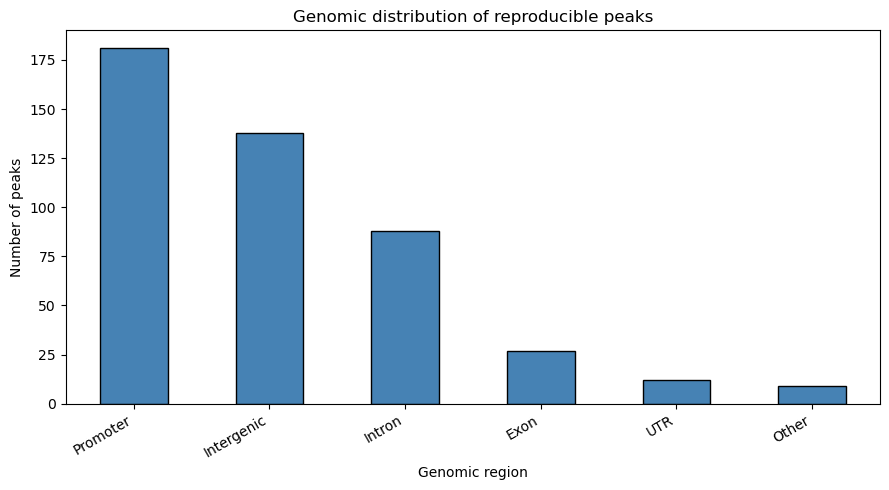

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

path = "bonus2/consensus/reproducible_peaks_annotated.txt"
df = pd.read_csv(path, sep="\t", comment="#")

ann = df["Annotation"].fillna("Unknown").astype(str)

def simplify_annotation(x):
    x = x.lower()
    if "promoter" in x:
        return "Promoter"
    if "tss" in x:
        return "TSS-related"
    if "5' utr" in x or "3' utr" in x or "utr" in x:
        return "UTR"
    if "exon" in x:
        return "Exon"
    if "intron" in x:
        return "Intron"
    if "intergenic" in x:
        return "Intergenic"
    return "Other"

df["SimpleAnnotation"] = ann.map(simplify_annotation)
counts = df["SimpleAnnotation"].value_counts().sort_values(ascending=False)

counts.to_csv("bonus2/consensus/reproducible_peaks_annotation_counts.tsv", sep="\t", header=["count"])

plt.figure(figsize=(9, 5))
counts.plot(kind="bar", color="steelblue", edgecolor="black")
plt.title("Genomic distribution of reproducible peaks")
plt.xlabel("Genomic region")
plt.ylabel("Number of peaks")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig("bonus2/consensus/reproducible_peaks_barplot.png", dpi=200, bbox_inches="tight")
print(counts.to_string())

In [21]:
%%bash


echo "ATH peaks:"
wc -l bonus2/macs3/ATH_peaks.narrowPeak

echo "OLG peaks:"
wc -l bonus2/macs3/OLG_peaks.narrowPeak

echo "Reproducible peaks:"
wc -l bonus2/consensus/reproducible_peaks.bed

echo
echo "Annotation counts:"
cat bonus2/consensus/reproducible_peaks_annotation_counts.tsv

ATH peaks:
1843 bonus2/macs3/ATH_peaks.narrowPeak
OLG peaks:
1043 bonus2/macs3/OLG_peaks.narrowPeak
Reproducible peaks:
455 bonus2/consensus/reproducible_peaks.bed

Annotation counts:
SimpleAnnotation	count
Promoter	181
Intergenic	138
Intron	88
Exon	27
UTR	12
Other	9


## Вывод

В работе выполнен базовый анализ ChIP-seq данных для двух реплик и контрольного образца.  
Получены пики, проведено сравнение с ENCODE, построены профили сигнала около TSS и проанализированы воспроизводимые пики.